# Konsolidasi Data Awal

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
from collections import Counter

#Root Proyek (Directory Searching)
root_project_path = "/content/drive/MyDrive/NayaAksara/"

def deep_scan_dataset(root_path):
    all_data = []
    valid_extensions = ('.png', '.jpg', '.jpeg')

    print(f"Mulai menyusuri direktori: {root_path} ...")


    for root, dirs, files in os.walk(root_path):
        if any(x in root for x in [".ipynb_checkpoints", "$RECYCLE.BIN", ".trash"]):
            continue

        for file in files:
            if file.lower().endswith(valid_extensions):
                label = os.path.basename(root)


                all_data.append({
                    "full_path": os.path.join(root, file),
                    "label": label,
                    "parent_folder": root
                })

    if not all_data:
        print("Tidak ditemukan gambar sama sekali. Coba cek path root-nya.")
        return None, []


    df_raw = pd.DataFrame(all_data)


    class_counts = df_raw['label'].value_counts().reset_index()
    class_counts.columns = ['Karakter', 'Jumlah Gambar']
    class_counts = class_counts.sort_values(by='Karakter')

    unique_characters = sorted(df_raw['label'].unique())


    print("\n" + "="*40)
    print("📊 HASIL PENYUSURAN DATASET TOTAL")
    print("="*40)
    print(class_counts.to_string(index=False))
    print("-" * 40)
    print(f"✅ Total Seluruh Gambar  : {len(df_raw)}")
    print(f"✅ Total Kelas Ditemukan : {len(unique_characters)}")
    print(f"✅ Daftar Karakter (Vocab):")
    print(unique_characters)
    print("="*40)

    return df_raw, unique_characters


df_total, vocab_found = deep_scan_dataset(root_project_path)

Mulai menyusuri direktori: /content/drive/MyDrive/NayaAksara/ ...

📊 HASIL PENYUSURAN DATASET TOTAL
  Karakter  Jumlah Gambar
        ba            217
        ca            211
        da            211
       dha            211
        ga            211
        ha            205
        ja            211
        ka            211
        la            211
        ma            211
        na            211
       nga            205
       nya            211
        pa            211
prediction             25
        ra            211
        sa            211
        ta            211
       tha            211
        wa            211
        ya            211
----------------------------------------
✅ Total Seluruh Gambar  : 4239
✅ Total Kelas Ditemukan : 21
✅ Daftar Karakter (Vocab):
['ba', 'ca', 'da', 'dha', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'prediction', 'ra', 'sa', 'ta', 'tha', 'wa', 'ya']


In [ ]:
import os
import pandas as pd

path_mapping = df_total.groupby(['label', 'parent_folder']).size().reset_index(name='Jumlah')


path_mapping = path_mapping.sort_values(by=['label', 'Jumlah'], ascending=[True, False])

print("🗺️  PETA LOKASI FILE NAYAAKSARA")
print("="*80)


current_label = ""
for _, row in path_mapping.iterrows():
    if row['label'] != current_label:
        print(f"\n  AKSARA: [{row['label'].upper()}]")
        current_label = row['label']

    print(f"   |-- {row['Jumlah']} gambar di: {row['parent_folder']}")

print("\n" + "="*80)

folder_summary = df_total['parent_folder'].value_counts().reset_index()
folder_summary.columns = ['Nama Folder', 'Total Gambar']

print("\nTOP 5 FOLDER PENYUMBANG DATA TERBANYAK:")
print(folder_summary.head(10).to_string(index=False))

🗺️  PETA LOKASI FILE NAYAAKSARA

  AKSARA: [BA]
   |-- 114 gambar di: /content/drive/MyDrive/NayaAksara/data/tulisanjelek/tulisanjelek/version/train/ba
   |-- 79 gambar di: /content/drive/MyDrive/NayaAksara/data/tulisanjelek/tulisantangan/ba
   |-- 24 gambar di: /content/drive/MyDrive/NayaAksara/data/tulisanjelek/tulisanjelek/version/val/ba

  AKSARA: [CA]
   |-- 108 gambar di: /content/drive/MyDrive/NayaAksara/data/tulisanjelek/tulisanjelek/version/train/ca
   |-- 79 gambar di: /content/drive/MyDrive/NayaAksara/data/tulisanjelek/tulisantangan/ca
   |-- 24 gambar di: /content/drive/MyDrive/NayaAksara/data/tulisanjelek/tulisanjelek/version/val/ca

  AKSARA: [DA]
   |-- 108 gambar di: /content/drive/MyDrive/NayaAksara/data/tulisanjelek/tulisanjelek/version/train/da
   |-- 79 gambar di: /content/drive/MyDrive/NayaAksara/data/tulisanjelek/tulisantangan/da
   |-- 24 gambar di: /content/drive/MyDrive/NayaAksara/data/tulisanjelek/tulisanjelek/version/val/da

  AKSARA: [DHA]
   |-- 108 gambar 

In [ ]:
import os
import shutil
from tqdm import tqdm

# 1. Tentukan Folder Tujuan Baru
master_dataset_path = "/content/drive/MyDrive/NayaAksara/Master_Dataset"

# 2. Buat Folder Master jika belum ada
if not os.path.exists(master_dataset_path):
    os.makedirs(master_dataset_path)

print(f"Memulai Konsolidasi ke: {master_dataset_path}")

# 3. Iterasi dari df_total
count = 0
for index, row in tqdm(df_total.iterrows(), total=len(df_total)):
    label = row['label']
    src_path = row['full_path']

    # Abaikan label sampah
    if label.lower() == 'prediction':
        continue

    # Buat sub-folder karakter (ha, na, ca, dst)
    dest_folder = os.path.join(master_dataset_path, label)
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    # Buat nama file unik (misal: 'ha_001.png') agar tidak tertimpa
    file_ext = os.path.splitext(src_path)[1]
    new_filename = f"{label}_{count:04d}{file_ext}"
    dest_path = os.path.join(dest_folder, new_filename)

    # Eksekusi Copy
    shutil.copy(src_path, dest_path)
    count += 1

print(f"\n✅ Selesai! {count} gambar berhasil disatukan di Master_Dataset.")

Memulai Konsolidasi ke: /content/drive/MyDrive/NayaAksara/Master_Dataset


100%|██████████| 4239/4239 [21:51<00:00,  3.23it/s]


✅ Selesai! 4214 gambar berhasil disatukan di Master_Dataset.


In [ ]:
import os
import pandas as pd

def audit_master_dataset(master_path):
    report = []
    mismatch_found = []

    print(f"Memulai audit setelah konsolidasi data di: {master_path}\n")

    # 1. List semua folder karakter
    labels = sorted([d for d in os.listdir(master_path) if os.path.isdir(os.path.join(master_path, d))])

    for label in labels:
        folder_path = os.path.join(master_path, label)
        files = os.listdir(folder_path)
        img_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        count = len(img_files)

        # 2. Cek apakah ada file yang "salah alamat" berdasarkan prefix nama
        for f in img_files:
            file_prefix = f.split('_')[0]
            if file_prefix != label:
                mismatch_found.append({
                    "file": f,
                    "harusnya_di": file_prefix,
                    "nyasar_di": label
                })

        report.append({"Karakter": label, "Jumlah Gambar": count})


    df_report = pd.DataFrame(report)
    print("📊 DISTRIBUSI GAMBAR PER KARAKTER:")
    print("="*40)
    print(df_report.to_string(index=False))
    print("="*40)
    print(f"Total Karakter: {len(labels)}")
    print(f"Total Gambar  : {df_report['Jumlah Gambar'].sum()}")


    if mismatch_found:
        print("\n🚨 PERINGATAN: Ditemukan file salah alamat!")
        df_mismatch = pd.DataFrame(mismatch_found)
        print(df_mismatch.to_string(index=False))
    else:
        print("\n✅ AMAN: Semua file berada di folder yang sesuai dengan labelnya.")


master_path = "/content/drive/MyDrive/NayaAksara/Master_Dataset"
audit_master_dataset(master_path)

Memulai audit setelah konsolidasi data di: /content/drive/MyDrive/NayaAksara/Master_Dataset

📊 DISTRIBUSI GAMBAR PER KARAKTER:
Karakter  Jumlah Gambar
      ba            217
      ca            211
      da            211
     dha            211
      ga            211
      ha            205
      ja            211
      ka            211
      la            211
      ma            211
      na            211
     nga            205
     nya            211
      pa            211
      ra            211
      sa            211
      ta            211
     tha            211
      wa            211
      ya            211
Total Karakter: 20
Total Gambar  : 4214

✅ AMAN: Semua file berada di folder yang sesuai dengan labelnya.


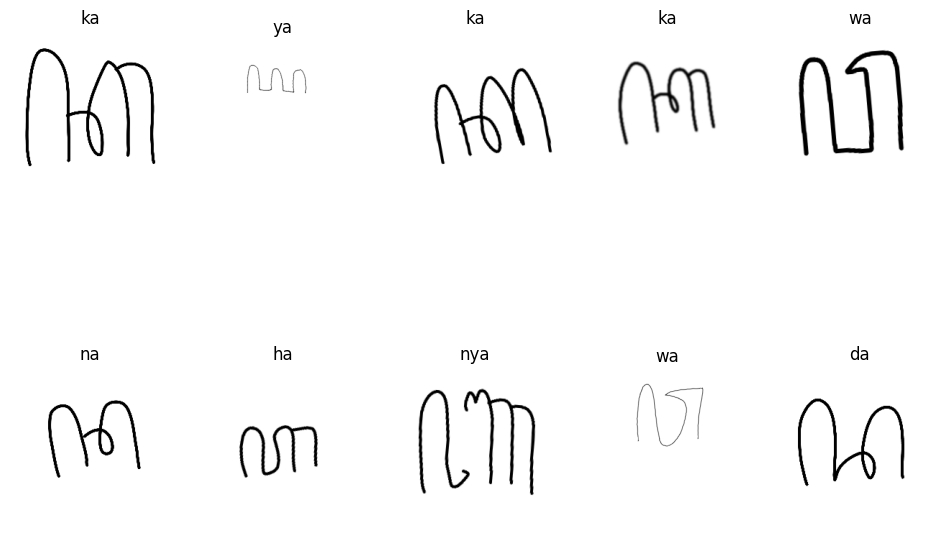

In [ ]:
import matplotlib.pyplot as plt
import random

def preview_master_data(base_path, vocab):
    plt.figure(figsize=(12, 8))
    for i in range(10):
        # Pilih random karakter dan random file
        char = random.choice(vocab)
        char_dir = os.path.join(base_path, char)
        fname = random.choice(os.listdir(char_dir))

        img = plt.imread(os.path.join(char_dir, fname))
        plt.subplot(2, 5, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(char)
        plt.axis('off')
    plt.show()

preview_master_data("/content/drive/MyDrive/NayaAksara/Master_Dataset", vocab_found)

In [ ]:
import os

master_path = "/content/drive/MyDrive/NayaAksara/Master_Dataset"
deleted_count = 0

print("🧹 Menyisir file korup di Master_Dataset...")

for root, dirs, files in os.walk(master_path):
    for f in files:
        file_path = os.path.join(root, f)

        # 1. Cek ukuran file (0 bytes)
        if os.path.getsize(file_path) == 0:
            print(f"🗑️ Menghapus file kosong: {file_path}")
            os.remove(file_path)
            deleted_count += 1
            continue

        # 2. Cek file sampah sistem (biasanya .DS_Store atau hidden files)
        if f.startswith('.') or f.startswith('desktop.ini'):
            os.remove(file_path)
            deleted_count += 1

print(f"\n✅ Selesai! Berhasil membersihkan {deleted_count} file pengganggu.")

🧹 Menyisir file korup di Master_Dataset...
🗑️ Menghapus file kosong: /content/drive/MyDrive/NayaAksara/Master_Dataset/ra/ra_0084.png
🗑️ Menghapus file kosong: /content/drive/MyDrive/NayaAksara/Master_Dataset/ra/ra_0155.png
🗑️ Menghapus file kosong: /content/drive/MyDrive/NayaAksara/Master_Dataset/ra/ra_0157.png
🗑️ Menghapus file kosong: /content/drive/MyDrive/NayaAksara/Master_Dataset/nya/nya_0407.png
🗑️ Menghapus file kosong: /content/drive/MyDrive/NayaAksara/Master_Dataset/dha/dha_0518.png
🗑️ Menghapus file kosong: /content/drive/MyDrive/NayaAksara/Master_Dataset/dha/dha_0550.png
🗑️ Menghapus file kosong: /content/drive/MyDrive/NayaAksara/Master_Dataset/ha/ha_0594.png
🗑️ Menghapus file kosong: /content/drive/MyDrive/NayaAksara/Master_Dataset/pa/pa_0633.png
🗑️ Menghapus file kosong: /content/drive/MyDrive/NayaAksara/Master_Dataset/pa/pa_0664.png
🗑️ Menghapus file kosong: /content/drive/MyDrive/NayaAksara/Master_Dataset/ta/ta_0737.png
🗑️ Menghapus file kosong: /content/drive/MyDrive/Na

In [ ]:
import os
from PIL import Image

master_path = "/content/drive/MyDrive/NayaAksara/Master_Dataset"
bad_files = 0

print("🔍 Memulai Deep Audit (Verifikasi Konten Gambar)...")

for root, dirs, files in os.walk(master_path):
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            file_path = os.path.join(root, f)
            try:
                # Coba buka dan verifikasi integritas file
                with Image.open(file_path) as img:
                    img.verify()

                # Tambahan: Coba load beneran (antisipasi file yang korup di tengah)
                with Image.open(file_path) as img:
                    img.load()

            except (IOError, SyntaxError, Image.UnidentifiedImageError) as e:
                print(f"🗑️ Menghapus file korup: {f} di {os.path.basename(root)}")
                os.remove(file_path)
                bad_files += 1

print(f"\n✅ Selesai! {bad_files} file korup telah dimusnahkan.")

🔍 Memulai Deep Audit (Verifikasi Konten Gambar)...
🗑️ Menghapus file korup: ra_0106.png di ra

✅ Selesai! 1 file korup telah dimusnahkan.
